In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

In [ ]:
# carga de los datos para entrenamiento y test.
datos_entrenamiento = pd.read_csv('Sign Language MNIST/sign_mnist_train/sign_mnist_train.csv')
datos_prueba = pd.read_csv('Sign Language MNIST/sign_mnist_test/sign_mnist_test.csv')

In [8]:
datos_entrenamiento.shape

(27455, 785)

In [9]:
datos_prueba.shape

(7172, 785)

In [10]:
print(f'''
datos entrenamiento:{datos_entrenamiento.info()}
''')


<class 'pandas.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB

datos entrenamiento:None



In [11]:
print(f'''
Datos de prueba: {datos_prueba.info()}''')

<class 'pandas.DataFrame'>
RangeIndex: 7172 entries, 0 to 7171
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 43.0 MB

Datos de prueba: None


In [12]:
# cantidad de pixeles 784 se obtiene el tamano de la imagen
print(f'Cantidad de pixeles {datos_entrenamiento.shape[1]-1}')
np.sqrt(784)

Cantidad de pixeles 784


np.float64(28.0)

In [13]:
# label, variable objetivo , verificamos los valores unicos para encontrar la cantidad de clases
clases = datos_entrenamiento['label'].unique()

In [14]:
# Separacion de datos para entramiento.
features_train = datos_entrenamiento.drop(columns='label')
label_train = datos_entrenamiento['label']

print(f'''Chequeo de dimensiones features and label
features : {features_train.shape}
label : {label_train.shape}''')

Chequeo de dimensiones features and label
features : (27455, 784)
label : (27455,)


In [15]:
# Separacion de datos para test
features_test = datos_prueba.drop(columns='label')
label_test= datos_prueba['label']
print(f'''
Chequeo de dimension para entrenamiento de test.
features_test : {features_test.shape}
label_test: {label_test}'''
)


Chequeo de dimension para entrenamiento de test.
features_test : (7172, 784)
label_test: 0        6
1        5
2       10
3        0
4        3
        ..
7167     1
7168    12
7169     2
7170     4
7171     2
Name: label, Length: 7172, dtype: int64


In [16]:
# Se procede a corroborar las caracteristicas y el valor de cada pixel con una intensidad de 0 a 255.
features_train.describe()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,...,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000
mean,145.419377,148.500273,151.247714,153.546531,156.210891,158.411255,160.472154,162.339683,163.954799,165.533673,...,141.104863,147.495611,153.325806,159.125332,161.969259,162.736696,162.906137,161.966454,161.137898,159.824731
std,41.358555,39.942152,39.056286,38.595247,37.111165,36.125579,35.016392,33.661998,32.651607,31.279244,...,63.751194,65.512894,64.427412,63.708507,63.738316,63.444008,63.509210,63.298721,63.610415,64.396846
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,121.000000,126.000000,130.000000,133.000000,137.000000,140.000000,142.000000,144.000000,146.000000,148.000000,...,92.000000,96.000000,103.000000,112.000000,120.000000,125.000000,128.000000,128.000000,128.000000,125.500000
50%,150.000000,153.000000,156.000000,158.000000,160.000000,162.000000,164.000000,165.000000,166.000000,167.000000,...,144.000000,162.000000,172.000000,180.000000,183.000000,184.000000,184.000000,182.000000,182.000000,182.000000
75%,174.000000,176.000000,178.000000,179.000000,181.000000,182.000000,183.000000,184.000000,185.000000,186.000000,...,196.000000,202.000000,205.000000,207.000000,208.000000,207.000000,207.000000,206.000000,204.000000,204.000000
max,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


- En el siguiente analisis de EDA, se procedera a realiza una normalizacion de los valores de los pixeles de las imagenes.
Donde cada imagen esta compuesta por una dimension 784 pixeles, correspondiente a una dimension de 28x28, los valores de intensidad de los pixeles van desde los 0-255, por lo que seran normalizados en un rango de 0 a 1.

In [17]:
# funcion normalizar
def normalizar(imagenes, etiquetas):
    """toma las imagenes como caracteristicas y 
    sus etiquetas correspondientes a la clase de cada imagen.
    las imagenes se convierten a un tipo de datos flotante y sus valores de intensidad
    originalmente va desde 0 a 255 valores de intensidad y se normalizan a un rango de 0 a 1.
    Args:
        imagenes (float64): caracteristica de cada imagen representadas
        mediante sus valores de pixeles.
        etiquetas (float64): clase correspondiente a cada imagen.

    Returns:
        float64: retorna un tupla que contiene los valores de intensidad normalizados
        en un rango de 0 a 1 y las etiquetas quedan sin modificar.
    """    
    imagenes = tf.cast(imagenes,tf.float32)
    imagenes/=255
    return imagenes, etiquetas

In [18]:
# Normalizacion de los datos para entrenamiento y test
#train
normalized_train, label_train = normalizar(features_train,label_train)
#test
normalized_test , label_test = normalizar(features_test,label_test)

### Distribución de Clases

In [19]:
class_distribution = label_train.value_counts(ascending=False)
difference = class_distribution.max() - class_distribution.min()
print(f'''
distribucion de clases : {class_distribution}
diferencia de clases con mayor imagen y menor imagen
{difference}''')



distribucion de clases : label
17    1294
16    1279
11    1241
22    1225
5     1204
18    1199
3     1196
14    1196
19    1186
23    1164
8     1162
20    1161
13    1151
2     1144
0     1126
24    1118
10    1114
6     1090
15    1088
21    1082
12    1055
7     1013
1     1010
4      957
Name: count, dtype: int64
diferencia de clases con mayor imagen y menor imagen
337


In [20]:
train_counts = {}
for class_number in clases:
    train_counts[class_number] = label_train.value_counts()[class_number]

train_counts


{np.int64(3): np.int64(1196),
 np.int64(6): np.int64(1090),
 np.int64(2): np.int64(1144),
 np.int64(13): np.int64(1151),
 np.int64(16): np.int64(1279),
 np.int64(8): np.int64(1162),
 np.int64(22): np.int64(1225),
 np.int64(18): np.int64(1199),
 np.int64(10): np.int64(1114),
 np.int64(20): np.int64(1161),
 np.int64(17): np.int64(1294),
 np.int64(19): np.int64(1186),
 np.int64(21): np.int64(1082),
 np.int64(23): np.int64(1164),
 np.int64(24): np.int64(1118),
 np.int64(1): np.int64(1010),
 np.int64(12): np.int64(1055),
 np.int64(11): np.int64(1241),
 np.int64(15): np.int64(1088),
 np.int64(4): np.int64(957),
 np.int64(0): np.int64(1126),
 np.int64(5): np.int64(1204),
 np.int64(7): np.int64(1013),
 np.int64(14): np.int64(1196)}

In [21]:
print(len(label_train))
print(len(label_test))

27455
7172


In [22]:
test_counts={}
for test_number in clases:
    test_counts[test_number] = label_test.value_counts()[test_number]
test_counts


{np.int64(3): np.int64(245),
 np.int64(6): np.int64(348),
 np.int64(2): np.int64(310),
 np.int64(13): np.int64(291),
 np.int64(16): np.int64(164),
 np.int64(8): np.int64(288),
 np.int64(22): np.int64(206),
 np.int64(18): np.int64(246),
 np.int64(10): np.int64(331),
 np.int64(20): np.int64(266),
 np.int64(17): np.int64(144),
 np.int64(19): np.int64(248),
 np.int64(21): np.int64(346),
 np.int64(23): np.int64(267),
 np.int64(24): np.int64(332),
 np.int64(1): np.int64(432),
 np.int64(12): np.int64(394),
 np.int64(11): np.int64(209),
 np.int64(15): np.int64(347),
 np.int64(4): np.int64(498),
 np.int64(0): np.int64(331),
 np.int64(5): np.int64(247),
 np.int64(7): np.int64(436),
 np.int64(14): np.int64(246)}

In [23]:
pd.set_option('display.max_rows',None)
difference_class = pd.DataFrame(
    {
        "class":clases,
        "train_counts" : [train_counts[c] for c in clases],
        "test_counts" : [test_counts[c] for c in clases]
    }
)
difference_class

,class,train_counts,test_counts
0,3,1196,245
1,6,1090,348
2,2,1144,310
3,13,1151,291
4,16,1279,164
5,8,1162,288
6,22,1225,206
7,18,1199,246
8,10,1114,331
9,20,1161,266


In [24]:
difference_class_long = difference_class.melt(
    id_vars="class",
    value_vars=['train_counts','test_counts']
)
difference_class_long.head()

,class,variable,value
0,3,train_counts,1196
1,6,train_counts,1090
2,2,train_counts,1144
3,13,train_counts,1151
4,16,train_counts,1279


In [25]:
difference_class_long['dataset'] = difference_class_long['variable'].map({
    'train_counts': 'Entrenamiento',
    'test_counts': 'Prueba'
})

Text(0.5, 1.0, 'Distribución de clases: entrenamiento vs prueba')

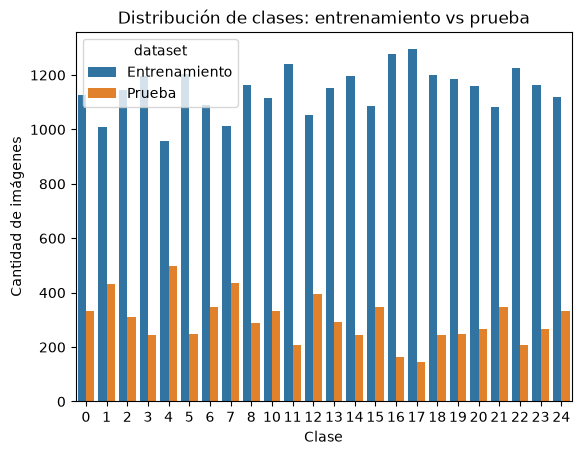

In [26]:
sns.barplot(data=difference_class_long,x='class',y='value',hue='dataset')
plt.ylabel('Cantidad de imágenes')
plt.xlabel('Clase')
plt.title('Distribución de clases: entrenamiento vs prueba')

In [27]:
# al normalizar los datos originales, las caracteristicas se convierten en tensores,por lo tanto se procede a construir un dataset.
# para organizar las caracteristicas y etiquetas.
# dataset train
dataset_train = tf.data.Dataset.from_tensor_slices((normalized_train,label_train))
# dataset test
dataset_test = tf.data.Dataset.from_tensor_slices((normalized_test,label_test))